### 1. Parse Change of Mind Behavior
Also insert into change-of-mind trial information into the table TrialChoiceChangeOfMind

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import spyglass as nd
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt
from ripple_detection.core import segment_boolean_series

from spyglass.common import (Session, IntervalList,LabMember, LabTeam, Raw, Session, Nwbfile,
                            Electrode,LFPBand,interval_list_intersect)
from spyglass.common import TaskEpoch
from spyglass.spikesorting.v0 import (SortGroup, 
                                    SpikeSortingRecording,SpikeSortingRecordingSelection)
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.common.common_position import IntervalPositionInfo, RawPosition, IntervalLinearizedPosition, TrackGraph

[2025-11-01 09:31:37,062][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [3]:
from spyglass.shijiegu.Analysis_SGU import TrialChoice,EpochPos,MUA,get_linearization_map, ChangeofMind
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.ripple_add_replay import plot_decode_spiking
from spyglass.shijiegu.changeOfMind import (insertTrialChoiceChangeOfMind, find_turnaround_time, findProportion,
            find_trials, load_epoch_data_wrapper, find_direction, find_trials_animal, unique_stable)

[09:32:10][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[09:32:10][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[09:32:10][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[09:32:10][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackG

ImportError: cannot import name 'find_turnaround_time' from 'spyglass.shijiegu.changeOfMind' (/home/shijiegu/Documents/spyglass/src/spyglass/shijiegu/changeOfMind.py)

## Section A. Insert

In [29]:
success = {}

In [40]:
success

{'Eliot': 1, 'Lewis': 1, 'Haydn': 1, 'Molly': 1, 'Klein': 1, 'Julio': 1}

In [30]:
animal = 'Eliot'
dates_to_plot = ['20221017','20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

In [ ]:
print(animal)
proportion_threshold = 0.05
trials_days = find_trials_animal(animal,
                                 dates_to_plot,
                                 proportion_threshold = proportion_threshold)

insertTrialChoiceChangeOfMind(trials_days,proportion_threshold = proportion_threshold)

proportion_threshold = 0.1
trials_days = find_trials_animal(animal,
                                 dates_to_plot,
                                 proportion_threshold = proportion_threshold)
insertTrialChoiceChangeOfMind(trials_days,proportion_threshold = proportion_threshold)

proportion_threshold = 0.2
trials_days = find_trials_animal(animal,
                                 dates_to_plot,
                                 proportion_threshold = proportion_threshold)
insertTrialChoiceChangeOfMind(trials_days,proportion_threshold = proportion_threshold)

success[animal] = 1

[11:45:17][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-06 11:45:17,051][WARNING]: Skipped checksum for file with hash: 0d661ee1-4eb4-9c8e-91b8-2f4c347f8865, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_9NQ9PCWYPI.nwb
[2025-10-06 11:45:17,076][WARNING]: Skipped checksum for file with hash: 0d661ee1-4eb4-9c8e-91b8-2f4c347f8865, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_9NQ9PCWYPI.nwb
[2025-10-06 11:45:17,084][WARNING]: Skipped checksum for file with hash: 0d661ee1-4eb4-9c8e-91b8-2f4c347f8865, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_9NQ9PCWYPI.nwb
[2025-10-06 11:45:17,172][WARNING]: Skipped checksum for file with hash: 796da31c-5e59-029b-11dd-b7a1

Eliot
currently investigating:
02_Seq2Session1
pos 1 valid times


[11:45:17][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


len(subset_linear)  501
currently investigating:
04_Seq2Session2
pos 3 valid times


[2025-10-06 11:45:17,518][WARNING]: Skipped checksum for file with hash: fc0ce1bd-9374-41a5-747c-5dd1371f1fe5, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_GKJQDF255C.nwb
[2025-10-06 11:45:17,537][WARNING]: Skipped checksum for file with hash: fc0ce1bd-9374-41a5-747c-5dd1371f1fe5, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_GKJQDF255C.nwb
[2025-10-06 11:45:17,544][WARNING]: Skipped checksum for file with hash: fc0ce1bd-9374-41a5-747c-5dd1371f1fe5, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_GKJQDF255C.nwb
[2025-10-06 11:45:17,614][WARNING]: Skipped checksum for file with hash: 678c0b56-0142-abda-72c7-c64b034d9c6d, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_2RTEYBOXJG.nwb
[2025-10-06 11:45:17,634][WARNING]: Skipped checksum for file with hash: 678c0b56-0142-abda-72c7-c64b034d9c6d, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_2RTEYBOXJG.nwb
[2025-10-06 11:45:17,640][WARNING]: Skipped checksum for file with hash: 67

...

[2025-10-06 12:17:53,309][WARNING]: Skipped checksum for file with hash: 10514451-1f9a-7b5d-cc59-748c547ac97e, and path: /stelmo/nwb/analysis/eliot20221026/eliot20221026_GZGRU0O0PV.nwb
[2025-10-06 12:17:53,325][WARNING]: Skipped checksum for file with hash: 10514451-1f9a-7b5d-cc59-748c547ac97e, and path: /stelmo/nwb/analysis/eliot20221026/eliot20221026_GZGRU0O0PV.nwb
[2025-10-06 12:17:53,329][WARNING]: Skipped checksum for file with hash: 10514451-1f9a-7b5d-cc59-748c547ac97e, and path: /stelmo/nwb/analysis/eliot20221026/eliot20221026_GZGRU0O0PV.nwb
[12:17:53][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-06 12:17:53,652][WARNING]: Skipped checksum for file with hash: a98d9b30-0cf9-698d-b0b2-eaa5

No change of mind on session 02_Seq2Session1


[12:18:05][INFO] Spyglass: Writing new NWB file eliot20221017_Y14LCQRVHH.nwb
INFO:spyglass:Writing new NWB file eliot20221017_Y14LCQRVHH.nwb
[12:18:12][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-06 12:18:12,321][WARNING]: Skipped checksum for file with hash: c2fdf5e4-b001-616f-ed23-bc50009939eb, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_A6XEMCLSR6.nwb
[2025-10-06 12:18:12,335][WARNING]: Skipped checksum for file with hash: c2fdf5e4-b001-616f-ed23-bc50009939eb, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_A6XEMCLSR6.nwb
[2025-10-06 12:18:12,341][WARNING]: Skipped checksum for file with hash: c2fdf5e4-b001-616f-ed23-bc50009939eb, and path: /stelmo/nwb/analysis/eli

No change of mind on session 04_Seq2Session2


[12:19:42][INFO] Spyglass: Writing new NWB file eliot20221018_8IZYOKN76Z.nwb
INFO:spyglass:Writing new NWB file eliot20221018_8IZYOKN76Z.nwb
[12:19:48][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-06 12:19:48,823][WARNING]: Skipped checksum for file with hash: ce99e605-08af-b498-0703-3754ad0a7958, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_LQ6YHHKJ3A.nwb
[2025-10-06 12:19:48,837][WARNING]: Skipped checksum for file with hash: ce99e605-08af-b498-0703-3754ad0a7958, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_LQ6YHHKJ3A.nwb
[2025-10-06 12:19:48,840][WARNING]: Skipped checksum for file with hash: ce99e605-08af-b498-0703-3754ad0a7958, and path: /stelmo/nwb/analysis/eli

In [ ]:
animal = 'Lewis'
dates_to_plot = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110','20240113','20240114','20240115','20240116','20240117','20240118','20240119','20240120']

print(animal)
proportion_threshold = 0.05
trials_days = find_trials_animal(animal,
                                 dates_to_plot,
                                 proportion_threshold = proportion_threshold)

insertTrialChoiceChangeOfMind(trials_days,proportion_threshold = proportion_threshold)

proportion_threshold = 0.1
trials_days = find_trials_animal(animal,
                                 dates_to_plot,
                                 proportion_threshold = proportion_threshold)
insertTrialChoiceChangeOfMind(trials_days,proportion_threshold = proportion_threshold)

proportion_threshold = 0.2
trials_days = find_trials_animal(animal,
                                 dates_to_plot,
                                 proportion_threshold = proportion_threshold)
insertTrialChoiceChangeOfMind(trials_days,proportion_threshold = proportion_threshold)

success[animal] = 1

In [ ]:
animal = 'Haydn'
dates_to_plot = ['20230603','20230604','20230605','20230606','20230607','20230608']

print(animal)
proportion_threshold = 0.05
trials_days = find_trials_animal(animal,
                                 dates_to_plot,
                                 proportion_threshold = proportion_threshold)

insertTrialChoiceChangeOfMind(trials_days,proportion_threshold = proportion_threshold)

proportion_threshold = 0.1
trials_days = find_trials_animal(animal,
                                 dates_to_plot,
                                 proportion_threshold = proportion_threshold)
insertTrialChoiceChangeOfMind(trials_days,proportion_threshold = proportion_threshold)

proportion_threshold = 0.2
trials_days = find_trials_animal(animal,
                                 dates_to_plot,
                                 proportion_threshold = proportion_threshold)
insertTrialChoiceChangeOfMind(trials_days,proportion_threshold = proportion_threshold)

success[animal] = 1

In [ ]:
animal = 'Molly'
dates_to_plot = ['20220415','20220416','20220417','20220418','20220419','20220420']

proportion_threshold = 0.05
trials_days = find_trials_animal(animal,
                                 dates_to_plot,
                                 proportion_threshold = proportion_threshold)

insertTrialChoiceChangeOfMind(trials_days,proportion_threshold = proportion_threshold)

proportion_threshold = 0.1
trials_days = find_trials_animal(animal,
                                 dates_to_plot,
                                 proportion_threshold = proportion_threshold)
insertTrialChoiceChangeOfMind(trials_days,proportion_threshold = proportion_threshold)

proportion_threshold = 0.2
trials_days = find_trials_animal(animal,
                                 dates_to_plot,
                                 proportion_threshold = proportion_threshold)
insertTrialChoiceChangeOfMind(trials_days,proportion_threshold = proportion_threshold)

success[animal] = 1

In [ ]:
animal = 'Klein'
# " 20231110 has problems "
dates_to_plot = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108','20231109','20231111']

In [ ]:
proportion_threshold = 0.05
trials_days = find_trials_animal(animal,
                                 dates_to_plot,
                                 proportion_threshold = proportion_threshold)

insertTrialChoiceChangeOfMind(trials_days,proportion_threshold = proportion_threshold)

proportion_threshold = 0.1
trials_days = find_trials_animal(animal,
                                 dates_to_plot,
                                 proportion_threshold = proportion_threshold)
insertTrialChoiceChangeOfMind(trials_days,proportion_threshold = proportion_threshold)

proportion_threshold = 0.2
trials_days = find_trials_animal(animal,
                                 dates_to_plot,
                                 proportion_threshold = proportion_threshold)
insertTrialChoiceChangeOfMind(trials_days,proportion_threshold = proportion_threshold)

success[animal] = 1

In [ ]:
animal = 'Julio'
# " 20231110 has problems "
dates_to_plot = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
proportion_threshold = 0.05
trials_days = find_trials_animal(animal,
                                 dates_to_plot,
                                 proportion_threshold = proportion_threshold)

insertTrialChoiceChangeOfMind(trials_days,proportion_threshold = proportion_threshold)

proportion_threshold = 0.1
trials_days = find_trials_animal(animal,
                                 dates_to_plot,
                                 proportion_threshold = proportion_threshold)
insertTrialChoiceChangeOfMind(trials_days,proportion_threshold = proportion_threshold)

proportion_threshold = 0.2
trials_days = find_trials_animal(animal,
                                 dates_to_plot,
                                 proportion_threshold = proportion_threshold)
insertTrialChoiceChangeOfMind(trials_days,proportion_threshold = proportion_threshold)

success[animal] = 1

In [ ]:
ChangeofMind() & {"nwb_file_name": "julio20230811_.nwb"}

## Section B. some simple plots

In [8]:
datafolder = '/cumulus/shijie/behavior_pilot/Batch1/Klein'

In [22]:
trials_days['20231101'][0][0]

[5, 11, 14, 21, 29, 40, 42, 56, 57, 67, 75, 76, 77, 78, 80]

In [23]:
# do some sum across sessions within day
trial_number = []
for k in trials_days:
    trial_number.append(np.sum([len(trial[0]) for trial in trials_days[k]]))

In [10]:
animal_cap = animal[0].upper() + animal[1:]

In [11]:
# load behavior data
sequence_datapath = os.path.join(datafolder,'behavior_metaSequence_'+animal_cap+'.p')
with open(sequence_datapath, 'rb') as f:
    behavior_data = pickle.load(f)  

In [12]:
total_trial_num = {}
occurance_rates = {}

for day in dates_to_plot:
    total_trial_num_day = 0
    occurance_rates_day = np.zeros(6)
    
    subset_ind = np.argwhere(behavior_data['dateIntAll'] == int(day)).ravel()
    for session_ind in subset_ind:
        total_trial_num_day = total_trial_num_day + len(behavior_data['outersAll'][session_ind])
        for seq in range(6):
            occurance_rates_day[seq] = occurance_rates_day[seq] + np.mean(behavior_data['occurance_rates'][seq][session_ind])
    occurance_rates_day = occurance_rates_day/len(subset_ind)
    
    total_trial_num[day] = total_trial_num_day
    occurance_rates[day] = occurance_rates_day

### plots

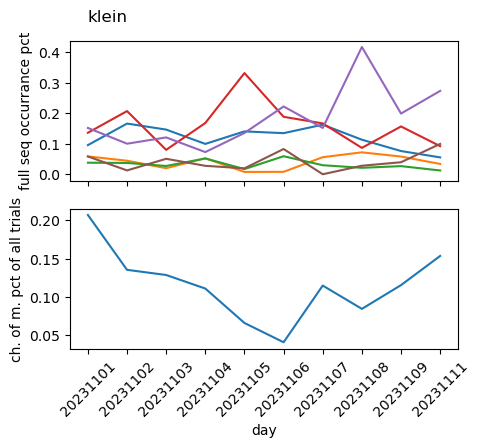

In [25]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 4),sharex=True)

ax1.plot([occurance_rates[k] for k in occurance_rates])
ax2.plot(np.array(trial_number) / np.array([total_trial_num[k] for k in total_trial_num]))

ax1.text(0,0.5,animal,fontsize = 12)
ax1.set_ylabel('full seq occurrance pct');
ax2.set_ylabel('ch. of m. pct of all trials');
ax2.set_xlabel('day');
ax2.set_xticks(np.arange(len(dates_to_plot)));
ax2.set_xticklabels(dates_to_plot, rotation = 45);